In [85]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
import torchvision.datasets as datasets
import torchvision.transforms as transforms
import torch.optim as optim
import torchvision
from torch.utils.tensorboard import SummaryWriter

In [15]:
class Generator(nn.Module):
    def __init__(self,z_dim,img_dim):
        super(Generator,self).__init__()
        self.gen=nn.Sequential(
            nn.Linear(z_dim,128),
            nn.LeakyReLU(0.1),
            nn.Linear(128,256),
            nn.LeakyReLU(0.1),
            nn.Linear(256,img_dim),
            nn.Tanh()
        )

    def forward(self,x):
        return self.gen(x)

In [22]:
class Discriminator(nn.Module):
    def __init__(self,img_dim):
        super(Discriminator,self).__init__()
        self.disc=nn.Sequential(
            nn.Linear(img_dim,256),
            nn.ReLU(inplace=True),
            nn.Linear(256,128),
            nn.ReLU(inplace=True),
            nn.Linear(128,1),
            nn.Sigmoid()
        )

    def forward(self,x):
        return self.disc(x)

In [21]:
device='cuda' if torch.cuda.is_available() else 'cpu'

In [90]:
device='cuda' if torch.cuda.is_available() else 'cpu'

z_dim=64
img_dim=28*28*1

batch_size=32
num_epochs=10
lr=3e-4

transforms=transforms.Compose(
    [
        transforms.ToTensor(),
        transforms.Normalize((0.5,),(0.5,))

    ]
)
dataset=datasets.MNIST(root='dataset/',transform=transforms,download=True)
dataloader=DataLoader(dataset=dataset,batch_size=batch_size,shuffle=True)

gen=Generator(z_dim,img_dim).to(device)
disc=Discriminator(img_dim).to(device)


fixed_noise=torch.randn(batch_size,z_dim).to(device)


torch.Size([1, 28, 28])
torch.Size([32])
tensor(6)


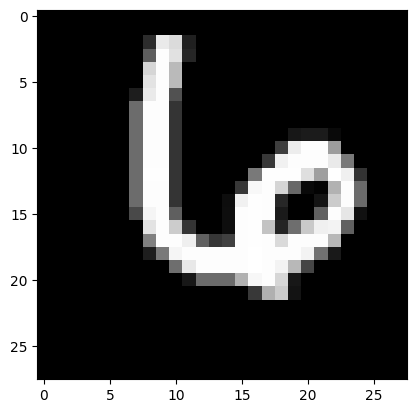

In [61]:
images,labels = next(iter(dataloader))
print(images[0].shape)
print(labels.shape)

print(labels[0])
import matplotlib.pyplot as plt
plt.imshow(images[0].squeeze(), cmap="gray")
plt.show()

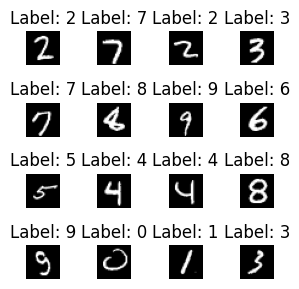

In [60]:
import matplotlib.pyplot as plt
images, labels = next(iter(dataloader))
fig, axes = plt.subplots(4, 4, figsize=(3,3))
for i, ax in enumerate(axes.flat):
    ax.imshow(images[i].squeeze(), cmap="gray")
    ax.set_title(f"Label: {labels[i].item()}")
    ax.axis("off")

plt.tight_layout()
plt.show()

In [88]:

optim_disc=optim.Adam(disc.parameters(),lr=lr)
optim_gen=optim.Adam(gen.parameters(),lr=lr)
criterion=nn.BCELoss()
# from torch.utils.tensorboard import SummaryWriter 
writer_fake = SummaryWriter(f"logs/fake")
writer_real = SummaryWriter(f"logs/real")
step=0

In [91]:

for epoch in range(num_epochs):
    for idx,(real_image,label) in enumerate(dataloader):

        real_image=real_image.view(-1,784).to(device)
        batch_size=real_image.shape[0]

        fake_noise=torch.randn(batch_size,z_dim).to(device)
        fake_image=gen(fake_noise)
        # train discriminator. loss disc(fake) +loss disc(real)
        disc_real=disc(real_image).view(-1)
        disc_loss_real=criterion(disc_real,torch.ones_like(disc_real))

        disc_fake=disc(fake_image).view(-1)
        disc_loss_fake=criterion(disc_fake,torch.zeros_like(disc_fake))
        
        disc_net_loss=(disc_loss_real + disc_loss_fake)/2

        optim_disc.zero_grad()
        disc_net_loss.backward(retain_graph=True)
        optim_disc.step()

        # train generator
        output = disc(fake_image).view(-1)
        gen_loss = criterion(output, torch.ones_like(output))
        gen.zero_grad()
        gen_loss.backward()
        optim_gen.step()


        if idx==0:
            print(f'Epoch{epoch}/ Total Epoch {num_epochs},Batch {idx}/{len(dataloader)} \
                , Discruiminator loss.{disc_net_loss:.4f} & Generator Loss {gen_loss:.4f}')
        

        with torch.no_grad():
                fake = gen(fixed_noise).reshape(-1, 1, 28, 28)
                data = real_image.reshape(-1, 1, 28, 28)
                img_grid_fake = torchvision.utils.make_grid(fake_image, normalize=True)
                img_grid_real = torchvision.utils.make_grid(data, normalize=True)

                writer_fake.add_image(
                    "Mnist Fake Images", img_grid_fake, global_step=step
                )
                writer_real.add_image(
                    "Mnist Real Images", img_grid_real, global_step=step
                )
                step += 1


Epoch0/ Total Epoch 10,Batch 0/1875                 , Discruiminator loss.0.6690 & Generator Loss 0.6908
Epoch1/ Total Epoch 10,Batch 0/1875                 , Discruiminator loss.0.6704 & Generator Loss 0.6917
Epoch2/ Total Epoch 10,Batch 0/1875                 , Discruiminator loss.0.6721 & Generator Loss 0.6906
Epoch3/ Total Epoch 10,Batch 0/1875                 , Discruiminator loss.0.6724 & Generator Loss 0.6914
Epoch4/ Total Epoch 10,Batch 0/1875                 , Discruiminator loss.0.6686 & Generator Loss 0.6908
Epoch5/ Total Epoch 10,Batch 0/1875                 , Discruiminator loss.0.6705 & Generator Loss 0.6908
Epoch6/ Total Epoch 10,Batch 0/1875                 , Discruiminator loss.0.6687 & Generator Loss 0.6908
Epoch7/ Total Epoch 10,Batch 0/1875                 , Discruiminator loss.0.6710 & Generator Loss 0.6914
Epoch8/ Total Epoch 10,Batch 0/1875                 , Discruiminator loss.0.6703 & Generator Loss 0.6910
Epoch9/ Total Epoch 10,Batch 0/1875                 , D